# Surface flux response to the net radiative forcing, DLR + SW_net

Companion to `turbulent_flux_response_to_DLR.ipynb`. That notebook regresses
every surface term on the downwelling longwave alone. This one regresses the
same terms on the **net radiative forcing** F = DLR + SW_net, which is the
forcer [Sledd et al. (2025)](https://doi.org/10.1029/2024JD042578) use
(their §3.2 and eq. 9, "LWD + SWN").

**Why the second forcer.** The question behind both notebooks is mixed-phase
cloud thinning in the Arctic winter. In polar night a thinner cloud changes
DLR and nothing else, so the two forcers coincide. In October and March a
thinner cloud also lets more shortwave through, and a perturbation that lowers
DLR by 1 W m⁻² raises SW_net at the same time. Regressing on DLR alone then
misattributes the shortwave part of the response — it appears as a *responder*
(f_SW) when it is really part of the *forcing*. Regressing on F puts it where
it belongs, and it is what makes these numbers comparable with Sledd's Fig. 3.

**What changes and what does not.** The estimator is identical: the same
moment matrix, the same cos-latitude weighting, the same population, one more
tracked column (`fnet_W_m2`). The partition has **four** terms instead of five,
because the shortwave has changed sides:

$$
R = \mathrm{LWD} - \mathrm{LWU} + SW_{net} + \mathrm{SH} + \mathrm{LH}
  = F - \mathrm{LWU} + \mathrm{SH} + \mathrm{LH}
$$

$$
1 = \underbrace{\frac{d(\mathrm{LWU})}{dF}}_{f_{LWU}}
  \;\underbrace{-\,\frac{d(\mathrm{SH})}{dF}}_{f_{SH}}
  \;\underbrace{-\,\frac{d(\mathrm{LH})}{dF}}_{f_{LH}}
  \;+\;\underbrace{\frac{d(R)}{dF}}_{f_{res}}
$$

where every flux on the right is ERA5's, positive downward, and the minus
signs convert SH and LH to the Sledd sense of energy *leaving* the surface.
That sign business is the first section below, because it is where a check of
this identity goes wrong.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import turbulent_flux_response as tfr

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use dpi=

# Set to a directory to write PNGs as well as display them; None displays only.
SAVE_DIR = Path("figures/turbulent_response")
DPI = 350

# What the scatter figures draw over the density. "default" is the
# cos(latitude)-weighted fit plus the mean of y in each x column; "regression"
# is the unweighted least-squares regression alone, as a thin solid black line.
# Both are accumulated in the same pass, so this can be changed on an existing
# `A` without reloading -- every figure cell below takes fit_mode= too.
FIT_MODE = "regression"

# Which of the two least-squares fits the scatter figures draw. "panel" uses
# the direction each panel declares as physically meaningful; "both" draws both
# so the 1/r^2 gap between them is visible. See "Which way to run the
# regression" below -- this is not a presentation choice.
FIT_ORIENT = "panel"

## Load the data

Identical options to `turbulent_flux_response_to_DLR.ipynb`, so every number
here is on the same 44 million cell-hours. The module now also reads `istl1`,
the top ice-layer temperature, for the closure test below.

In [2]:
A = tfr.prepare(
    region="barrow",
    years=tuple(range(2014, 2026)),   # season START years -> 2022/23 .. 2025/26
    season_start=(10, 1),
    season_end=(3, 31),

    # --- cloud phase: fractional scheme, same values as
    # --- comparison_with_Genie_Obs.ipynb
    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.850,           # IWP/CWP at or above this = ice only
                                      # (mixed phase is everything else)
    # min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    # min_iwp=0.01,                     # g m-2, ice below this counts as absent
    min_lwp=2.0,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.95,          # overcast gate (Genie notebook: 0.909)
    fit_mode=FIT_MODE,                # scatter overlay; changeable without reload
    lsm_tol=0.01,                     # land-sea mask tolerance
    open_ocean_max_siconc=0.05,       # below this: open ocean
    sea_ice_min_siconc=0.95,          # above this: pack ice; between: MIZ
    storage="local",
    dpi=DPI,
)

Turbulent flux response to longwave forcing, by surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid-bearing: liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 2/0.01 g m-2
  Precip     : no precipitation filter

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0

## 1. The sign convention, and why a naive sum of slopes does not reach one

This came up as a real question: adding the four regression slopes
d(ULR)/d(DLR) + d(SH)/d(DLR) + d(LH)/d(DLR) + d(SW_net)/d(DLR) gave 0.78 over
land, the residual slope gave 0.12, and they did not sum to one. Does ERA5 fail
to conserve energy? No. The sum was mixing two sign conventions.

**ERA5 stores every flux positive downward.** That includes `msshf`, `mslhf`,
`msnswrf` and — crucially — `msnlwrf`, which is the *net* longwave LWD − LWU.
The upwelling longwave used in these notebooks is *derived*:
LWU = LWD − msnlwrf, a positive number representing an upward magnitude. The
moment it is pulled out that way, it is no longer in the positive-downward
convention that the other three fluxes are in, and it cannot be added to them
with the same sign.

The intuition "if the terms sum to zero at equilibrium, the signs take care of
themselves" is correct — *provided every term is in the same convention*. In
ERA5's own convention the balance is

$$
\mathtt{msnlwrf} + \mathtt{msnswrf} + \mathtt{msshf} + \mathtt{mslhf} = G
$$

with G the flux into the subsurface, also positive downward. Differentiate
with respect to DLR, remembering that d(msnlwrf)/d(DLR) = 1 − d(LWU)/d(DLR):

$$
\underbrace{\big(1 - f_{LWU}\big)}_{d(\mathtt{msnlwrf})/d\mathrm{DLR}}
+ \frac{d(\mathtt{msnswrf})}{d\mathrm{DLR}}
+ \frac{d(\mathtt{msshf})}{d\mathrm{DLR}}
+ \frac{d(\mathtt{mslhf})}{d\mathrm{DLR}} = \frac{dG}{d\mathrm{DLR}}
$$

Over land that is (1 − 0.831) + (−0.001) + 0.024 + (−0.071) = **0.121**, which
*is* the residual slope. No flipping anywhere. The error was using +0.831 (the
upward magnitude) where ERA5's own convention needs +0.169 (the net,
downward-positive).

Rearranging the same identity gives the Sledd et al. form, eq. 9, in which
every responder is counted as energy *leaving* the surface:

$$
1 = f_{LWU} \;-\; \frac{d(\mathtt{msshf})}{d\mathrm{DLR}}
  \;-\; \frac{d(\mathtt{mslhf})}{d\mathrm{DLR}}
  \;-\; \frac{d(\mathtt{msnswrf})}{d\mathrm{DLR}} \;+\; \frac{dG}{d\mathrm{DLR}}
$$

The minus signs are not a change of physics. They are what moving a term
across the equals sign looks like when that term was stored downward-positive
and is now being counted as an outflow. Sledd's statement "turbulent fluxes are
defined as positive when directed away from the surface" (their eq. 1) is the
same thing said as a convention.

**On "SH and LH aren't necessarily upward."** Right, and it does not matter.
A convention says what *positive* means, not which way the flux actually goes.
An ERA5 sensible heat flux of −20 W m⁻² is 20 W m⁻² upward. The slope
d(msshf)/d(DLR) = +0.024 over land says that as DLR rises the flux becomes 0.024
W m⁻² *more downward* (or less upward) per W m⁻²; in Sledd's convention the
identical physical change reads d(SH_up)/d(DLR) = −0.024. Nothing about the
direction of the mean flux enters — only the direction the *change* is counted
in.

The cell below prints all three forms for every class.

In [3]:
tfr.print_sign_convention_check(A)

Closure of the DLR regression, three ways   (cos-lat weighted)
  class                 d(LWU)   d(SH)   d(LH)   d(SW)    d(R)  | row1: native  row2: ERA5 row3: Sledd
                        up-mag   down+   down+   down+   down+  | LWU+SH+LH+SWNLW+SW+SH+LHLWU-SH-LH-SW+R
  Land                   0.831   0.024  -0.071  -0.001   0.120  |        0.783       0.120      1.0000
  Coastal (mixed)        0.794   0.082  -0.107   0.009   0.189  |        0.778       0.189      1.0000
  Open ocean             0.138   1.417   0.861   0.042   3.182  |        2.458       3.182      1.0000
  Marginal ice zone      0.632   0.233  -0.001   0.007   0.606  |        0.870       0.606      1.0000
  Sea ice                0.551   0.097   0.023  -0.015   0.554  |        0.655       0.554      1.0000
  Utqiagvik (ARM site)   0.815   0.011  -0.107   0.009   0.097  |        0.727       0.097      1.0000
  row1 should NOT equal anything.  row2 should equal d(R).  row3 should equal 1.


## 2. Does ERA5 conserve energy at the skin? Documentation, then data

**Documentation.** The IFS solves a zero-heat-capacity skin balance for every
tile, [IFS Cy41r2 Part IV](https://www.ecmwf.int/en/elibrary/79697-ifs-documentation-cy41r2-part-iv-physical-processes)
eq. 8.22:

$$
(1-f_{Rs,i})(1-\alpha_i)R_s + \varepsilon\left(R_T - \sigma T_{sk,i}^4\right)
+ H_i + L_{v,s}E_i = \Lambda_{sk,i}\left(T_{sk,i} - T_1\right)
$$

The document states the property directly: *"The surface energy balance is
satisfied independently for each tile by calculating its skin temperature"*
(§3.5, above eq. 3.73). And the right-hand side is not discarded — Table 8.12
gives the upper boundary condition of the ice-temperature equation as
F_I = H_N, *"the net heat flux at the surface, obtained from the solution of
the ice skin thermal budget"* (§8.9, below eq. 8.150). So whatever the skin
does not radiate or give to the atmosphere is conducted into the ice column,
exactly, every timestep. That is energy conservation at the skin by
construction.

**But the regression identity cannot test it.** With the subsurface defined as
the remainder, the five fractions sum to one algebraically — the same is true
of any set of numbers whose last member is defined as one minus the rest. A
real test needs the subsurface flux from somewhere *else*, which is what Sledd
et al. had (ice-mass-balance buoys) and why their winter closure of 0.9–1.0 is
a finding rather than an identity.

**ERA5 supplies that independent term for sea ice.** The archive carries
`istl1`, the temperature of the top 0.07 m ice layer. Conduction from the skin
into that layer is the right-hand side of eq. 8.22:

$$
G_{ice} = \Lambda_{sk}\left(T_{sk} - T_{1}\right), \qquad
\Lambda_{sk} = \frac{2\,\lambda_I}{D_1} = \frac{2 \times 2.03}{0.07} = 58.0
\ \mathrm{W\,m^{-2}\,K^{-1}}
$$

That Λ_sk is **inferred**: the extracted IFS text tabulates skin conductivity
for land tiles only, where "ice caps and glaciers" is 58.0, and the
sea-ice column's own numbers give 58.0 exactly, so the same value is assumed.
The figure below is therefore a test of that inference as much as of the
balance.

**What the test found.** Three things, in order of how much they matter.

*The grid-mean skin temperature is contaminated by open water at every
concentration below one.* `skt` is the tile-weighted mean and the open-water
tile sits at the freezing point, 271.46 K, roughly 15 K warmer than a winter
ice skin. Mean (skt − T₁) is **+3.4 K at 50% ice and still +0.2 K at
95–99.99%**, falling to **−0.025 K only at siconc = 1 exactly** — where it
finally has the sign winter physics requires, conduction upward. Two per cent
of open water is enough to flip the sign of G_ice. So the "sea ice" class
(siconc > 0.95) cannot be used for this test; only the pure-ice bin can, and
the siconc bins were modified so that bin exists (it also turned out that
siconc = 1.0 was being dropped from the MIZ transect by an edge effect — a
third of all ocean cell-hours).

*In the pure-ice bin the slope is consistent with closure once the time-base
noise is accounted for.* Regressing R on G_ice gives slope 0.47 and r² = 0.41.
Errors-in-variables bracket the effective Λ_sk at 27–68 W m⁻² K⁻¹; the upper
value is the case where the noise lives in the end-of-hour temperature
difference rather than in the hourly-mean R, which is the plausible one, and
it sits within 17% of the inferred 58. The implied noise in ΔT is 0.35 K rms,
a reasonable size for what a skin temperature does inside one hour. The
regression-side check agrees: dG_ice/dDLR = 0.43 against f_res = 0.56.

*The mean does not close, and noise cannot explain a mean.* R averages
**−9.3 W m⁻²** in the pure-ice bin, G_ice **−1.4**. The best-supported reason
is that the two sides come from different model states: the
[ERA5 terminology page](https://confluence.ecmwf.int/pages/viewpage.action?pageId=85402030)
states that the CDS serves *analysis* fields wherever they exist, and mean-rate
fluxes exist *only from the forecast*. So `skt` and `istl1` carry observation
increments — satellite skin temperature is assimilated — while the fluxes are
what the forecast computed from its own, pre-increment skin. The forecast
conserves energy internally; the archived pairing does not have to. An
analysis that warms the skin relative to the forecast would push (skt − T₁)
toward zero, which is the direction seen. This is a hypothesis, not a
demonstration — testing it needs the forecast-stream `skt` from MARS, which
the CDS does not expose.

**Conclusion.** Energy conservation at the skin is a property of the IFS by
construction (eq. 8.22, Table 8.12), and the pure-ice data are consistent with
it in slope and in the regression response. The archived output cannot verify
it to Sledd's ~10% because the skin temperature and the fluxes are not from the
same model state. That is a limit of ERA5 as a product, not evidence against
the model — and it is one more reason the residual, not a temperature-derived
conduction, is the right subsurface estimate to carry.


In [4]:
tfr.self_check(A)

self-check passed: every identity holds to 1e-09 across 7 groups


True

  -> figures/turbulent_response/barrow_ice_closure_transect_cloud_mean2014-2025.png


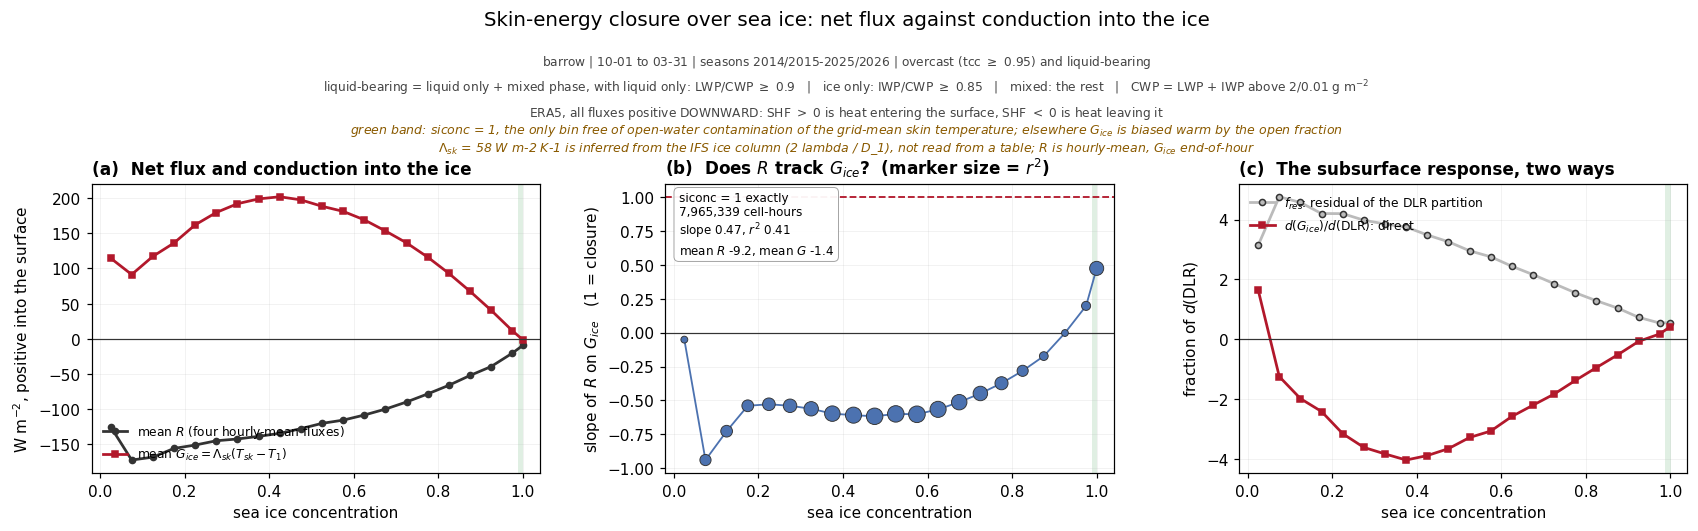

In [5]:
tfr.fig_ice_closure_transect(A, out_dir=SAVE_DIR, dpi=DPI);

In [6]:
# The closure numbers per sea-ice-concentration bin. Only the last bin
# (siconc = 1 exactly) is a fair test: everywhere else the grid-mean skt
# carries the warm open-water tile and G_ice is biased. The two rightmost
# columns are the subsurface response reached two ways -- as the remainder of
# the DLR partition and as the direct regression of the independent G_ice.
ice = A.ice_acc(); edges = A.sec["siconc_edges"]
print(f"{'siconc':>12}{'hours':>12}{'mean R':>8}{'mean G':>8}{'skt-T1':>8}"
      f"{'slope':>7}{'icpt':>7}{'r2':>6}  |{'f_res':>7}{'dG/dDLR':>9}")
for b in range(len(edges) - 1):
    c = tfr.ice_closure(ice, b)
    if not (c["n_hours"] >= 5000): continue
    dT = tfr.mean_of(ice, b, "skt_K") - tfr.mean_of(ice, b, "istl1_K")
    tag = "  <- pure ice" if b == tfr.PURE_ICE_BIN else ""
    print(f"{edges[b]:5.2f}-{edges[b+1]:<6.4g}{c['n_hours']:>12,.0f}{c['r_mean']:>8.1f}"
          f"{c['g_mean']:>8.1f}{dT:>8.3f}{c['slope']:>7.2f}{c['intercept']:>7.1f}"
          f"{c['r2']:>6.2f}  |{c['f_res_dlr']:>7.3f}{c['dgice_dlwd']:>9.3f}{tag}")

      siconc       hours  mean R  mean G  skt-T1  slope   icpt    r2  |  f_res  dG/dDLR
 0.00-0.05     6,544,355  -124.5   114.7   1.978  -0.05 -118.6  0.00  |  3.137    1.655
 0.05-0.1        204,871  -172.1    91.3   1.575  -0.94  -86.4  0.21  |  4.762   -1.239
 0.10-0.15       185,982  -168.0   117.1   2.019  -0.73  -83.0  0.24  |  4.570   -1.975
 0.15-0.2        185,876  -155.6   136.1   2.347  -0.54  -82.2  0.25  |  4.201   -2.407
 0.20-0.25       198,058  -150.8   161.8   2.790  -0.53  -65.4  0.30  |  4.198   -3.146
 0.25-0.3        209,402  -144.7   179.4   3.094  -0.54  -48.0  0.36  |  3.979   -3.604
 0.30-0.35       219,039  -142.2   191.9   3.309  -0.56  -34.5  0.43  |  3.852   -3.822
 0.35-0.4        246,722  -138.5   198.7   3.426  -0.60  -19.9  0.52  |  3.751   -4.026
 0.40-0.45       264,728  -134.2   201.8   3.479  -0.61  -11.5  0.57  |  3.486   -3.877
 0.45-0.5        282,827  -127.5   197.4   3.403  -0.62   -5.9  0.60  |  3.260   -3.646
 0.50-0.55       306,811  -120.0

### 2a. What open water does to the grid-mean skin temperature

The closure test could only be read from siconc = 1 because the skin
temperature everywhere else is not the ice's. The figure below shows the
mechanism and answers the question it raises for the surface classes: is
`siconc > 0.95` too low a threshold for "pack ice"?

**Panel (a).** `skt` is the tile-weighted grid mean (IFS §8.2). Over a sea
point the tiles are ice and open water, and the open-water tile sits at ERA5's
prescribed 271.46 K — 10 to 25 K warmer than a winter ice skin. So

$$
\mathtt{skt} = c\,T_{ice} + (1-c)\,271.46\ \mathrm{K}
$$

warms the grid mean by (1 − c)(271.46 − T_ice) over the true ice skin. The
dashed line is that expression with the pure-ice median held fixed; it is a
*floor* on the warming. The data sit well above it at intermediate
concentration because the ice in a half-covered cell is itself warmer — thinner,
younger, closer to the edge, and more often an October hour. Both effects push
the same way.

**Panel (b) is the decisive one.** skt − istl1 is the temperature difference
the skin-to-ice conduction is built from, and it mixes a *grid-mean* skin with
an *ice-tile* subsurface. Winter pack ice must have the skin colder than the
ice below — heat conducts up from the ocean. ERA5 shows the opposite at every
concentration below one: +3 K at 50%, +0.75 K at 90–95%, **+0.04 K at
95–99.99%**, and only at siconc = 1 exactly does it turn negative (−0.33 K).
The sign flips inside the "pack ice" class.

**Is 0.95 too low?** It depends entirely on what the class is used for.

| quantity, Oct–Mar all-sky | siconc 0.95–0.9999 | siconc = 1 | difference |
|---|---|---|---|
| cell-hours | 15.3 M | 6.2 M | class is 71% the first |
| median skt | −22.46 °C | −22.71 °C | 0.25 °C |
| mean skt | −21.64 °C | −22.11 °C | 0.47 °C |
| median skt − T₁ | +0.043 K | −0.327 K | **sign flips** |

And for the DLR partition (cloud population), the two halves of the class:

| | f_LWU | f_SH | f_LH | f_SW | f_res | dT_skin/dDLR |
|---|---|---|---|---|---|---|
| siconc 0.95–0.9999 | 0.549 | −0.097 | −0.022 | 0.025 | 0.545 | 0.1405 |
| siconc = 1 | 0.561 | −0.095 | −0.022 | −0.007 | 0.563 | 0.1458 |
| class, > 0.95 | 0.551 | −0.097 | −0.023 | 0.015 | 0.554 | 0.1415 |

- **For the flux regressions — everything in both notebooks that regresses a
  flux on DLR — 0.95 is fine.** The two halves of the class agree to within
  0.02 in every partition term and within 4% in dT_skin/dDLR. The fluxes are
  grid means too, so they carry the same open-water fraction as the skin
  temperature does, and the regression sees a consistent surface. No change to
  the class definition is warranted for that work.
- **For anything that treats `skt` as the temperature of ice — the skin-to-ice
  conduction, the closure test, a comparison with an ice-surface thermometer —
  0.95 is far too low, and so is 0.96, 0.98 or 0.99.** The contamination is
  monotonic in the open fraction and reaches zero only at c = 1. A threshold of
  0.96 would roughly halve the warm bias of the 0.95–1 bin and still flip the
  sign of skt − T₁. Use siconc = 1 exactly, which is 34% of ocean cell-hours on
  this strip — plenty of data.

**Panel (c), against MOSAiC.** Sledd et al. (2025) Fig. 2b gives the observed
skin temperature over pack ice at the Central Observatory, month by month, all
sky. The boxes here are digitised from a high-resolution copy of that panel,
reading each edge against the 10 °C gridlines, to about ±0.7 °C; the median
line and the mean star are read separately, since in March they sit on
opposite sides of the box. Pure-ice ERA5 (siconc = 1) against MOSAiC:

| | ERA5 median | ERA5 IQR | MOSAiC median | MOSAiC mean | MOSAiC IQR | ERA5 − MOSAiC median |
|---|---|---|---|---|---|---|
| Oct | −14.7 | 5.0 | −15.8 | −16.7 | 8.8 | +1.1 |
| Nov | −19.5 | 6.2 | −20.8 | −20.8 | 9.0 | +1.3 |
| Dec | −23.5 | 7.1 | −25.3 | −24.8 | 8.3 | +1.8 |
| Jan | −25.1 | 6.5 | −29.3 | −28.6 | 5.5 | +4.2 |
| Feb | −25.0 | 6.7 | −28.4 | −27.2 | 10.5 | +3.4 |
| Mar | −20.9 | 9.8 | −29.6 | −31.0 | 8.5 | +8.7 |

(°C throughout.) Four things to read:

- *October to December agree to within 2 °C.* ERA5 at Barrow is 1.1–1.8 °C
  warmer than MOSAiC through freeze-up and early winter, which is about what
  10 degrees of latitude is worth and well inside the spread of either.
- *The gap opens in deep winter and is largest in March.* +4 °C in January,
  +3 °C in February, **+9 °C in March**. MOSAiC's median stays near −29 °C
  from January through March while its mean keeps falling, to −31 °C in March
  — the distribution is skewed cold late in the season, with a whisker to
  −45 °C. ERA5 at Barrow does the opposite, warming from −25 to −21 °C between
  January and March. That is the returning sun at 71 °N, which 85 °N does not
  see in March, and it is real rather than a bias. What cannot be separated
  here is how much of the January–February gap is latitude and how much is the
  missing-snow warm bias of Batrak and Müller (2019), 5–10 °C in winter, which
  pushes the same way. Separating them needs ERA5 sampled along the MOSAiC
  track.
- *The spread is comparable.* ERA5's interquartile range over pure ice is
  5–10 °C by month; MOSAiC's is 5.5–10.5 °C. Whiskers span 20–36 °C in ERA5 and
  21–29 °C at MOSAiC. ERA5 is slightly narrower in October–February and wider in
  March. It is not collapsing the variability.
- *October is where the class threshold bites hardest.* The 0.95–0.9999 boxes
  sit 3 °C above pure ice in October, when the pack is forming and leads are
  warm, and nearly coincide with it from December on.


  -> figures/turbulent_response/barrow_skt_by_siconc_all_mean2014-2025.png


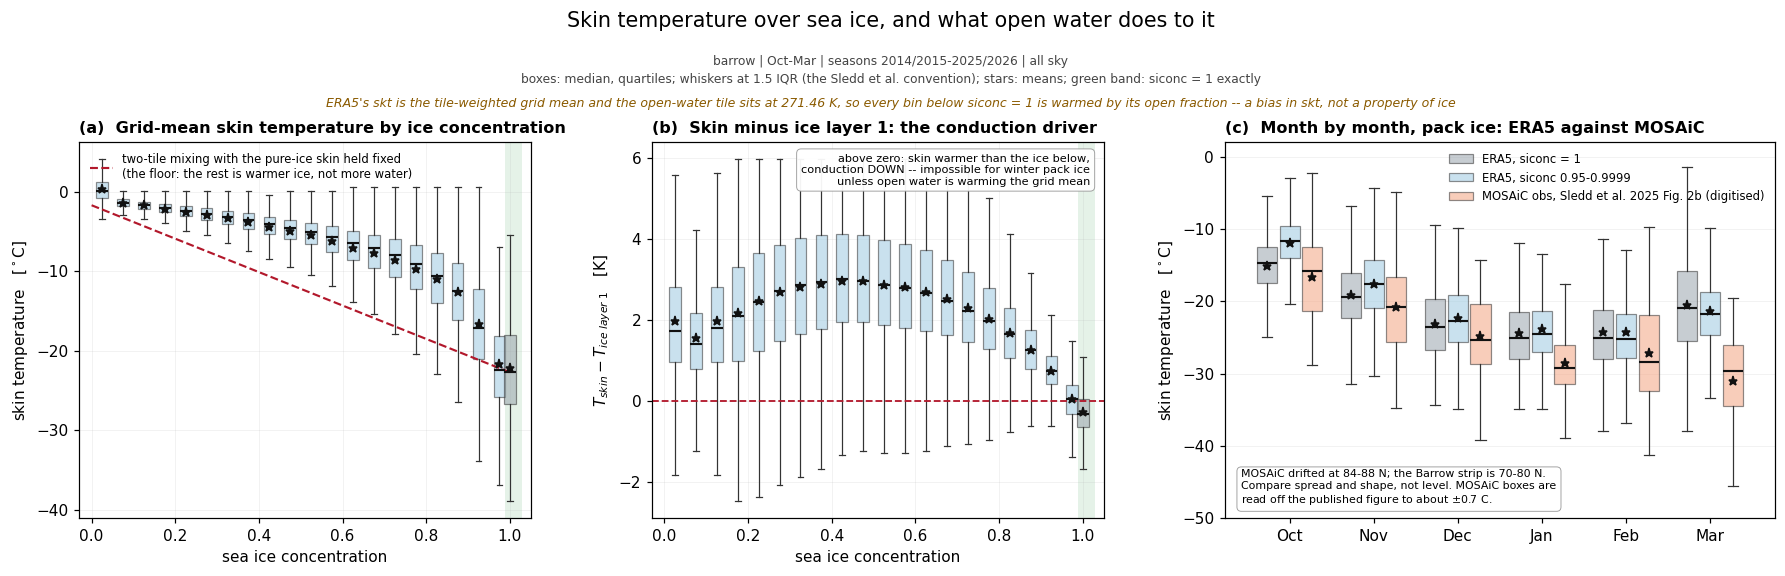

In [7]:
tfr.fig_skt_by_siconc(A, out_dir=SAVE_DIR, dpi=DPI, population="all");

## 3. The four responders against DLR + SW_net

Same figures as §4a of the DLR notebook — density scatter, unweighted
least-squares line in black, equation and r² in the box — with the forcer
changed. Each slope is one term of the four-way partition in §4.

  -> figures/turbulent_response/barrow_lwu_vs_fnet_regression_y_on_x_mean2014-2025.png


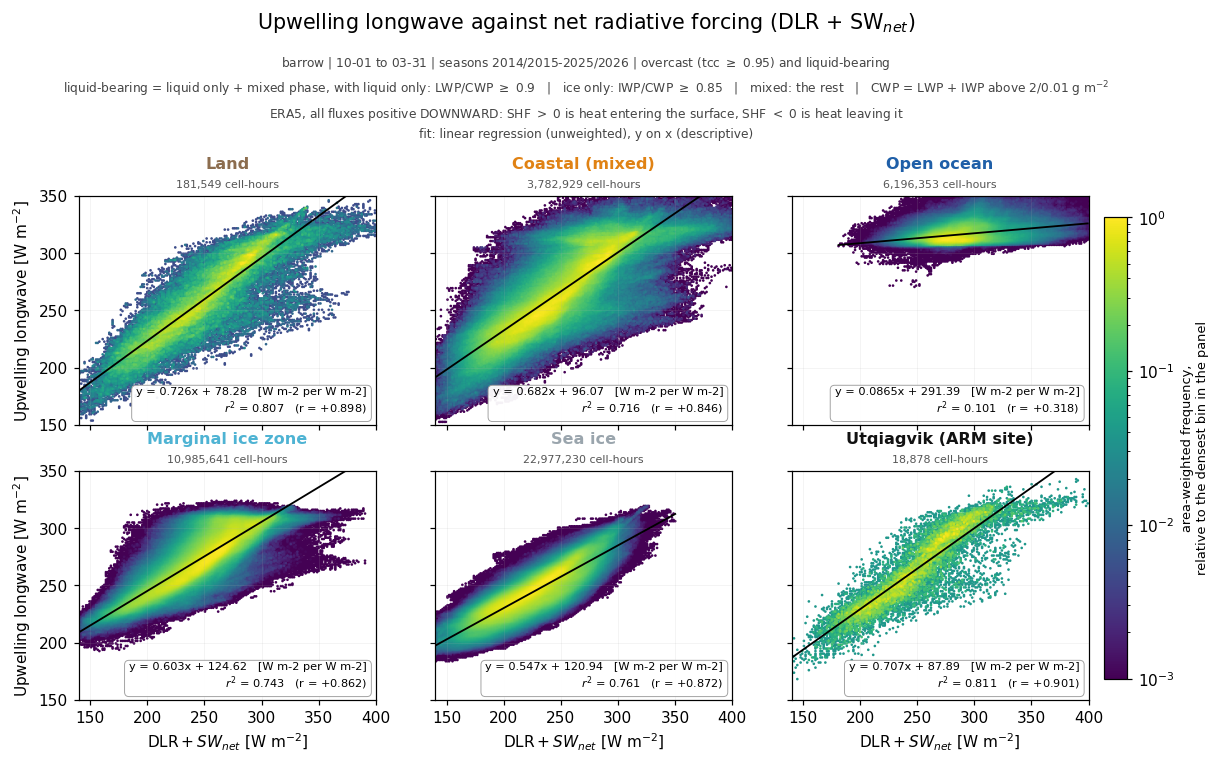

In [8]:
tfr.fig_lwu_vs_fnet(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

  -> figures/turbulent_response/barrow_shf_vs_fnet_regression_y_on_x_mean2014-2025.png


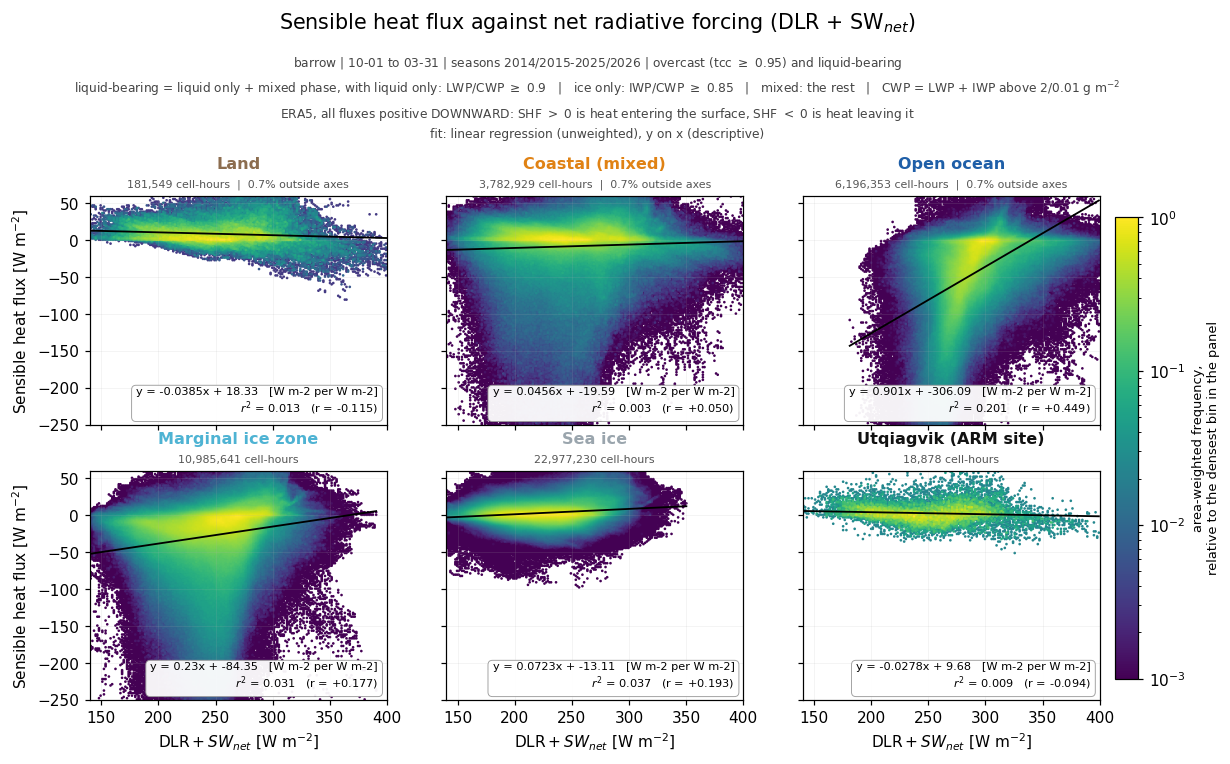

In [9]:
tfr.fig_shf_vs_fnet(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

  -> figures/turbulent_response/barrow_lhf_vs_fnet_regression_y_on_x_mean2014-2025.png


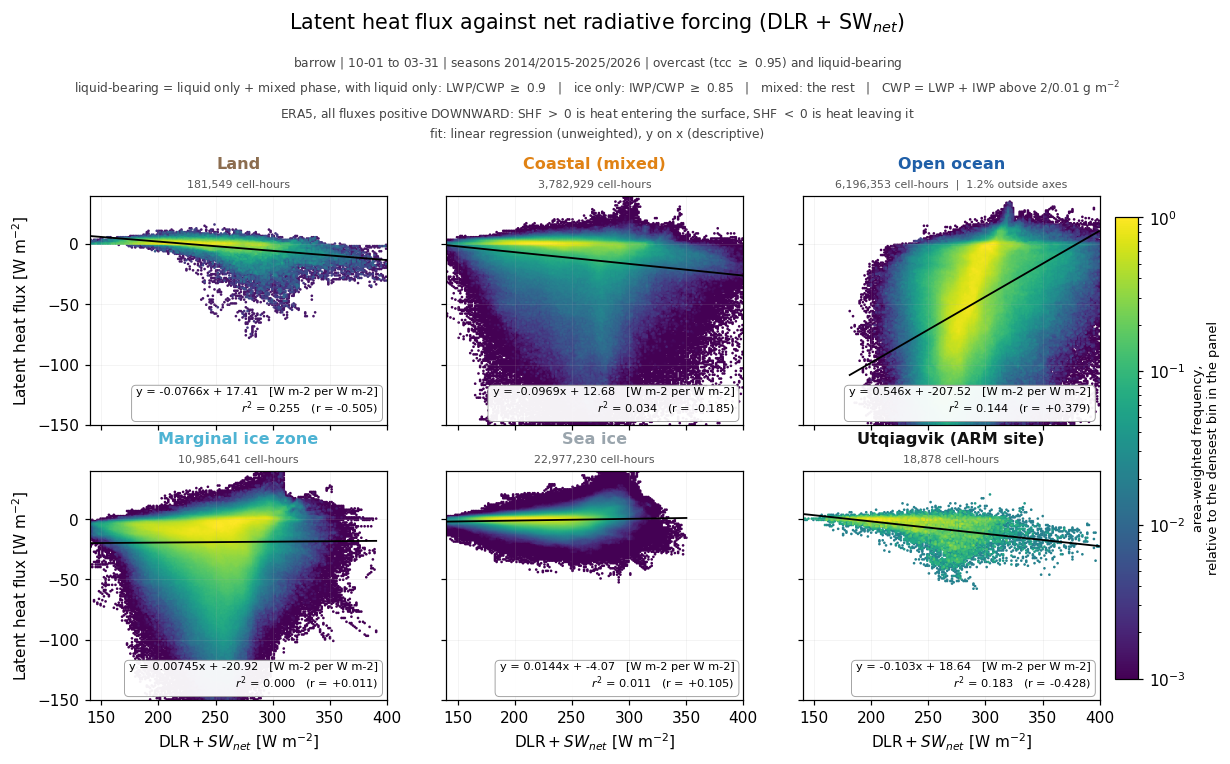

In [10]:
tfr.fig_lhf_vs_fnet(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

  -> figures/turbulent_response/barrow_rnet_vs_fnet_regression_y_on_x_mean2014-2025.png


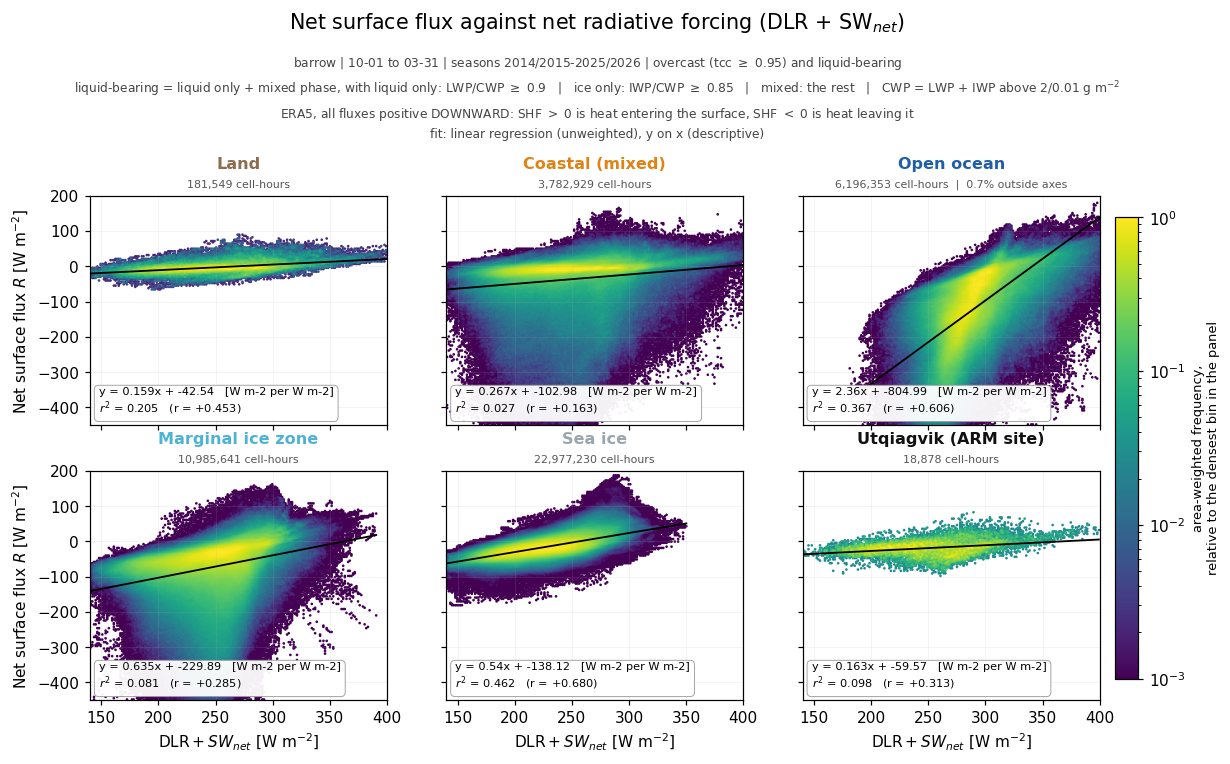

In [11]:
tfr.fig_rnet_vs_fnet(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

## 4. The partition on the two forcers, side by side

Left, the five-term partition on DLR from the other notebook; right, the
four-term partition on F = DLR + SW_net. Grouped rather than stacked so the
sign is visible. Mean SW_net over this population is only 2–8 W m⁻², so the two
differ mainly through October and March; in December and January they are the
same numbers.

  -> figures/turbulent_response/barrow_partition_forcer_cloud_none_mean2014-2025.png


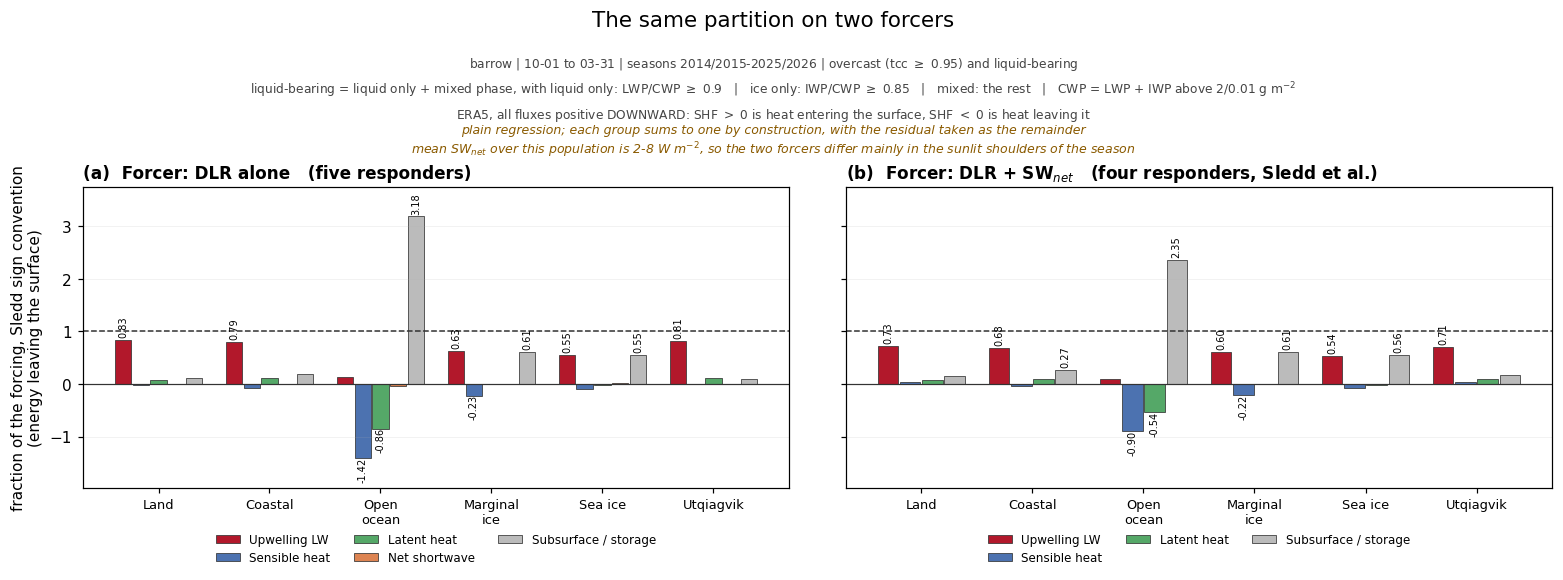

In [12]:
tfr.fig_partition_forcer(A, out_dir=SAVE_DIR, dpi=DPI);

In [13]:
acc = A.acc()
print(f"{'class':<20}{'forcer':>8}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}"
      f"{'f_SW':>8}{'f_res':>8}{'sum':>9}{'dTsk/dF':>9}")
for slot in tfr.PANEL_SLOTS:
    nm = tfr.SLOT_LABELS[tfr.SLOT_ORDER[slot]]
    a = tfr.partition(acc, slot); b = tfr.partition_fnet(acc, slot)
    print(f"{nm:<20}{'DLR':>8}{a['f_lwu']:>8.3f}{a['f_sh']:>8.3f}{a['f_lh']:>8.3f}"
          f"{a['f_sw']:>8.3f}{a['f_res']:>8.3f}"
          f"{a['f_lwu']+a['f_sh']+a['f_lh']+a['f_sw']+a['f_res']:>9.5f}"
          f"{a['dskt_dlwd']:>9.4f}")
    print(f"{'':<20}{'DLR+SW':>8}{b['f_lwu']:>8.3f}{b['f_sh']:>8.3f}{b['f_lh']:>8.3f}"
          f"{'--':>8}{b['f_res']:>8.3f}"
          f"{b['f_lwu']+b['f_sh']+b['f_lh']+b['f_res']:>9.5f}{b['dskt_dfnet']:>9.4f}")

class                 forcer   f_LWU    f_SH    f_LH    f_SW   f_res      sum  dTsk/dF
Land                     DLR   0.831  -0.024   0.071   0.001   0.120  1.00000   0.2074
                      DLR+SW   0.726   0.039   0.077      --   0.159  1.00000   0.1812
Coastal (mixed)          DLR   0.794  -0.082   0.107  -0.009   0.189  1.00000   0.1946
                      DLR+SW   0.682  -0.045   0.096      --   0.267  1.00000   0.1669
Open ocean               DLR   0.138  -1.417  -0.861  -0.042   3.182  1.00000   0.0274
                      DLR+SW   0.090  -0.902  -0.542      --   2.353  1.00000   0.0181
Marginal ice zone        DLR   0.632  -0.233   0.001  -0.007   0.606  1.00000   0.1526
                      DLR+SW   0.603  -0.218   0.005      --   0.610  1.00000   0.1453
Sea ice                  DLR   0.551  -0.097  -0.023   0.015   0.554  1.00000   0.1415
                      DLR+SW   0.539  -0.079  -0.016      --   0.556  1.00000   0.1385
Utqiagvik (ARM site)     DLR   0.815  -0.01

## 4a. The partition month by month, and against MOSAiC

The counterpart of Sledd et al. (2025) Fig. 2a, on their forcer. One panel per
surface class, October to March, the four responders regressed on
DLR + SW_net within each (class, month). Marker size scales with r²; no
confidence bands (see the DLR notebook for why); the four fractions sum to one
by construction so the "total" is not drawn.

  -> figures/turbulent_response/barrow_monthly_response_fnet_cloud_mean2014-2025.png


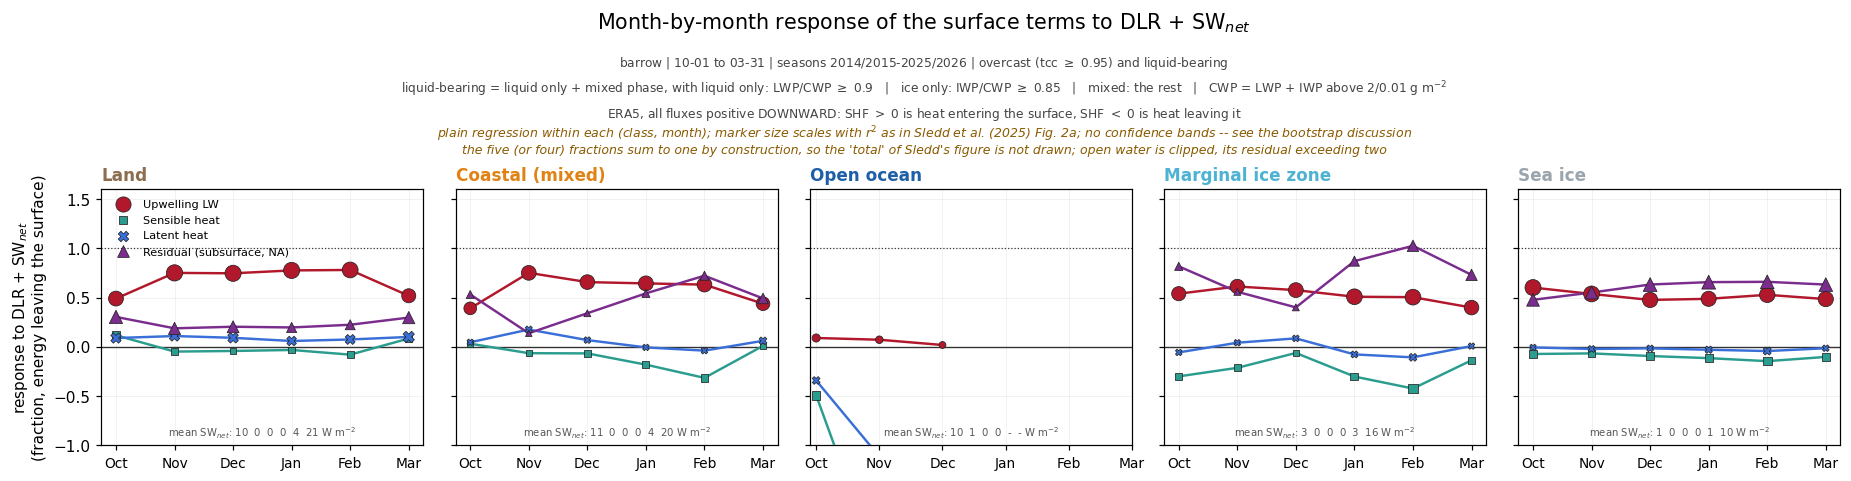

In [14]:
tfr.fig_monthly_response(A, forcer="fnet", out_dir=SAVE_DIR, dpi=DPI);

#### A slide version

Same regression, cut down for a talk: land, open ocean and sea ice, each
with its own y-axis; fixed marker size. `layout="row"` puts the three panels side by side at
about 2.8:1, which fills the width of a 16:9 slide under its title;
`layout="column"` (the default, used in the DLR notebook) stacks them.

**Sign convention.** The full figure above uses Sledd's convention, every term
counted as energy *leaving* the surface so that the fractions sum to one. This
one defaults to ERA5's own (`convention="era5"`, or `--sign-convention` on the
command line): positive is a change in *downward* flux, into the surface;
negative is into the atmosphere. So the upwelling-longwave term is negative
(the skin emits more), a turbulent loss that weakens shows as a positive
change, and the residual — already the net flux into the surface — keeps its
sign. `convention="sledd"` reproduces the full figure's signs.

**Colours.** `palette="sledd"` (the default, or `--monthly-palette` on the
command line) uses the full figure's scheme so the two read alike;
`palette="slide"` switches to `MONTHLY_STYLE_SIMPLE`, a palette kept clear of
the class colours and the red/blue used elsewhere in the talk (purples
radiative, greens turbulent, magenta residual). The file name carries both the
sign convention and the palette.

  -> figures/turbulent_response/barrow_monthly_response_simple_fnet_cloud_sledd_sledd_wide_mean2014-2025.png


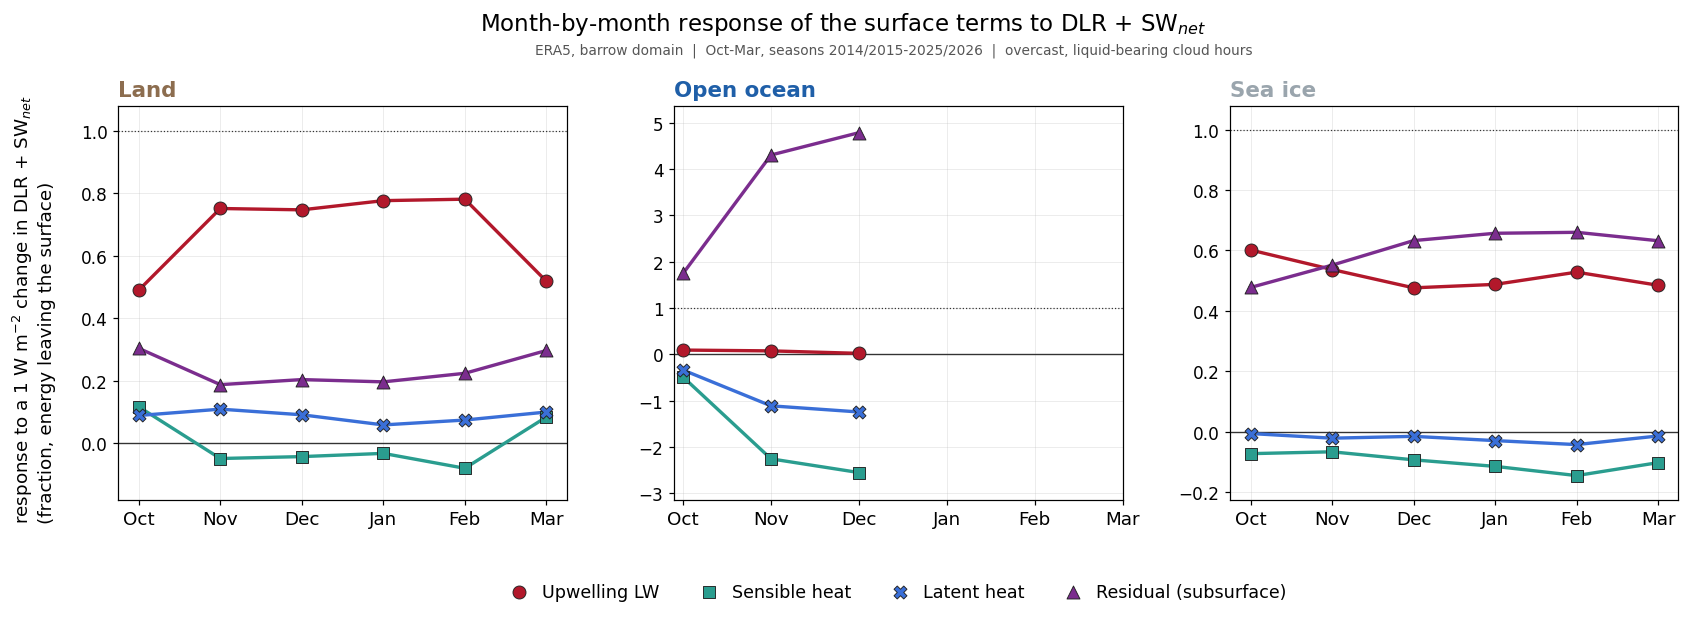

In [20]:
tfr.fig_monthly_response_simple(A, forcer="fnet", layout="row", out_dir=SAVE_DIR, dpi=DPI, convention="sledd");

#### The same figure, normalised by the sum of magnitudes

`fig_monthly_response_simple_normalized` divides each term by the sum of
magnitudes across the terms present,

$$
s_k = \frac{f_k}{\sum_j |f_j|}
$$

so every value lies in [−1, 1] and the magnitudes sum to one: the share of the
*gross* flux change per W m⁻² of forcing that each channel carries. It is a
description of which channels move, and by how much relative to each other —
**not a partition of the forcing**, and the difference matters exactly where a
channel turns into a source. Where no term is negative the denominator is one
and the shares are the partition itself (land in October and March). Where a
term is negative the denominator exceeds one and every share shrinks: over pack
ice in February the partition puts 0.66 of the forcing into the ice, the share
is 0.48; over open water the turbulent terms are sources of 2–3 W m⁻² per
W m⁻², and the shares measure the size of that co-variation. The sign
convention is applied before normalising. `signed=False` plots |f_k| / Σ|f_j|,
all in [0, 1] with no sign to explain, at the cost of no longer showing which
channels are sources.

  -> figures/turbulent_response/barrow_monthly_response_simple_norm_fnet_cloud_era5_sledd_abs_wide_mean2014-2025.png


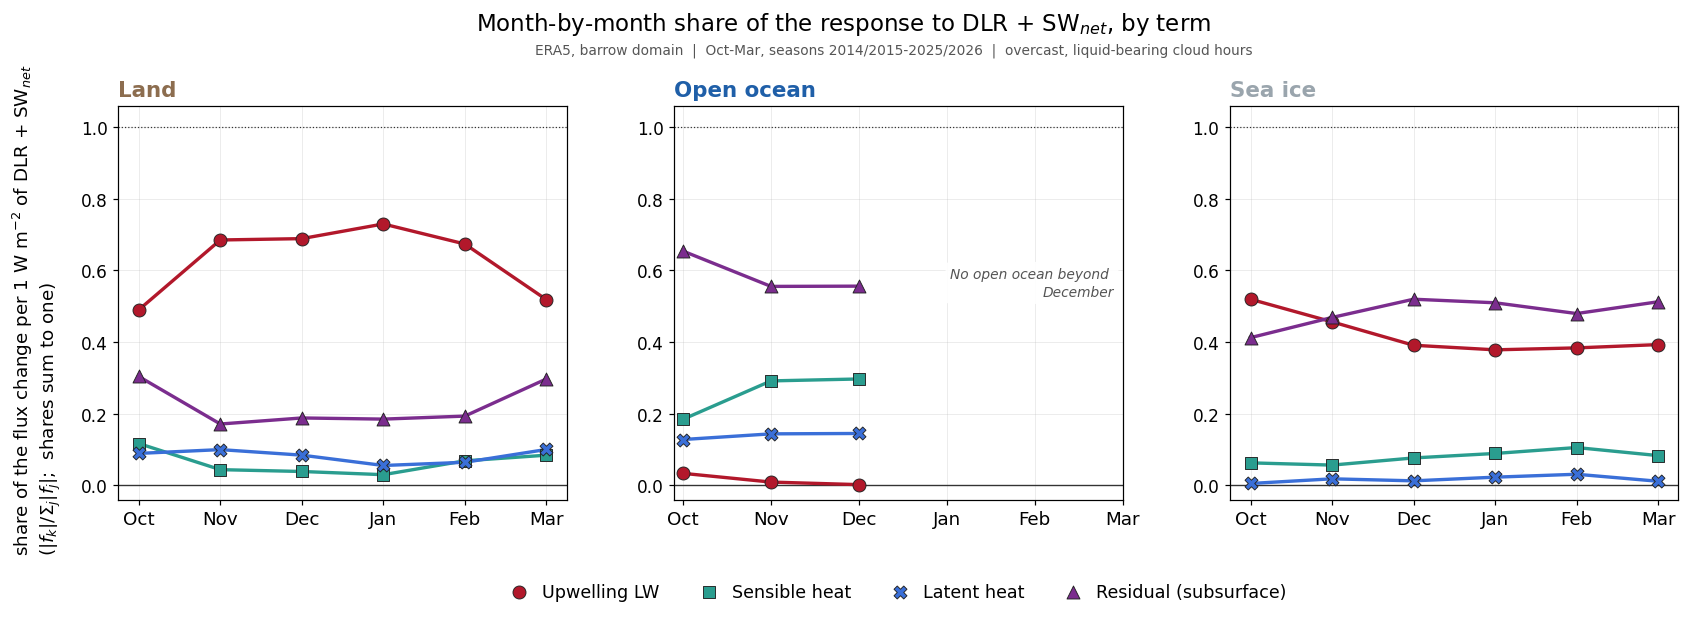

In [24]:
tfr.fig_monthly_response_simple_normalized(A, forcer="fnet", layout="row", out_dir=SAVE_DIR, dpi=DPI, signed=False);

#### Is this figure different from the DLR-only one?

At a glance the two monthly figures look the same, and for November to
February they are: the standard deviation of SW_net inside a (class, month)
group is under 3 W m⁻² against 27–35 W m⁻² for DLR, so DLR + SW_net is DLR to
within a percent of its variance and every slope agrees to ±0.02. October
and March are a different matter. There the spread of SW_net (15–32 W m⁻²)
is comparable to that of DLR, and the two regressions answer different
questions. On DLR alone, SW_net is a *responder*: in March over land its
correlation with DLR is −0.23 (a brighter-DLR hour is a thicker-cloud, dimmer
hour), and the regression books that lost shortwave as f_SW ≈ +0.21. On
DLR + SW_net the shortwave co-variation is inside the forcer, and the four
remaining terms re-partition — over land in March, LWU 0.71 → 0.52,
sensible heat −0.16 → +0.08, residual 0.17 → 0.30. The sunlit part of the
forcing is a midday pulse into an unstable boundary layer, and the surface
sends more of it up as sensible heat and down into storage than it does a
synoptic-scale DLR anomaly. The table gives the difference (DLR + SW_net
minus DLR) for every class and month.

In [17]:
import numpy as np

# Month by month: how far the DLR + SW_net partition sits from the DLR-only
# one, and the spread of SW_net against DLR that decides it.
acc = A.month_acc()
print(f"{'class':<18}{'mon':>5}{'sd SW':>7}{'sd DLR':>8}{'r(SW,DLR)':>10}"
      f"{'dLWU':>8}{'dSH':>7}{'dLH':>7}{'dres':>8}   (fnet - lwd)")
for name in tfr.CLASS_ORDER:
    slot = tfr.SLOT_ORDER.index(name)
    rl = tfr.monthly_partition(A, slot, "lwd")
    rf = tfr.monthly_partition(A, slot, "fnet")
    first = True
    for i, (m, lab) in enumerate(zip(tfr.WINTER_MONTHS, tfr.WINTER_LABELS)):
        if not rl["n_hours"][i] >= 5000:
            continue
        s = tfr.moment_stats(acc, tfr.month_group(m, slot), "lwd_W_m2", "swnet_W_m2")
        r_txt = f"{s['r']:10.2f}" if np.isfinite(s["r"]) else f"{'-':>10}"
        print(f"{tfr.SLOT_LABELS[name] if first else '':<18}{lab:>5}"
              f"{s['y_sd']:7.1f}{s['x_sd']:8.1f}{r_txt}"
              f"{rf['f_lwu'][i] - rl['f_lwu'][i]:8.3f}{rf['f_sh'][i] - rl['f_sh'][i]:7.3f}"
              f"{rf['f_lh'][i] - rl['f_lh'][i]:7.3f}{rf['f_res'][i] - rl['f_res'][i]:8.3f}")
        first = False

class               mon  sd SW  sd DLR r(SW,DLR)    dLWU    dSH    dLH    dres   (fnet - lwd)
Land                Oct   21.2    25.8      0.00  -0.151  0.124  0.019   0.008
                    Nov    1.8    30.9      0.08  -0.003  0.001 -0.001  -0.001
                    Dec    0.0    31.9     -0.00   0.000  0.000  0.000   0.000
                    Jan    0.5    33.9     -0.03   0.000  0.000  0.000   0.000
                    Feb    8.3    35.5     -0.09  -0.011  0.017  0.001   0.013
                    Mar   32.2    35.1     -0.23  -0.191  0.242  0.030   0.128
Coastal (mixed)     Oct   21.8    23.0      0.04  -0.180  0.126  0.035  -0.015
                    Nov    1.9    29.0      0.10  -0.004  0.003  0.001  -0.006
                    Dec    0.0    29.4         -   0.000  0.000  0.000   0.000
                    Jan    0.4    32.3     -0.00  -0.000 -0.000  0.000   0.000
                    Feb    8.0    34.9     -0.10  -0.007  0.018  0.004   0.007
                    Mar   30.0    33.

### ERA5 pack ice against the MOSAiC responses

Sledd's Fig. 2a values for October–March, digitised from a high-resolution copy
against the 0.2 gridlines to about ±0.02 (the reading reproduces their "total"
line to within 0.025 in every month):

| | Oct | Nov | Dec | Jan | Feb | Mar |
|---|---|---|---|---|---|---|
| LWU | 0.535 | 0.530 | 0.500 | 0.440 | 0.565 | 0.535 |
| SH | 0.150 | 0.125 | 0.250 | 0.215 | 0.130 | 0.320 |
| LH | 0.020 | 0.005 | 0.025 | 0.010 | −0.010 | 0.005 |
| −G (buoys) | 0.240 | 0.280 | 0.210 | 0.320 | 0.255 | 0.235 |
| NA (residual) | 0.285 | 0.335 | 0.220 | 0.335 | 0.310 | 0.120 |
| total measured | 0.940 | 0.940 | 0.960 | 0.995 | 0.945 | 1.075 |

The figure below puts ERA5's pack-ice class beside these, one panel per term.
Two ERA5 populations are drawn: **all sky** (solid), which is the like-for-like
comparison since Sledd regress every observation, and **liquid-bearing
overcast** (dashed), the population the rest of these notebooks use. The
residual panel carries both MOSAiC series — NA, the atmospheric-side remainder
and the direct counterpart of f_res, and −G, the buoy measurement of the same
flux. Their separation is the observational closure error, which ERA5 cannot
show because its residual is defined to close.

What to keep in mind reading it: MOSAiC is one winter at 84–88 °N over a
single floe; ERA5 here is twelve winters over ~1,700 grid cells at 70–80 °N.
And Sledd's own Fig. 3a puts the IFS — ERA5's model — at LWU ≈ 0.40,
SH ≈ 0, NA ≈ 0.60 over the same floe: too little longwave response and no
turbulent response, the balance carried by conduction, which they attribute to
the missing snow layer. That is the pattern to look for.

  -> figures/turbulent_response/barrow_monthly_vs_mosaic_sea_ice_fnet_mean2014-2025.png


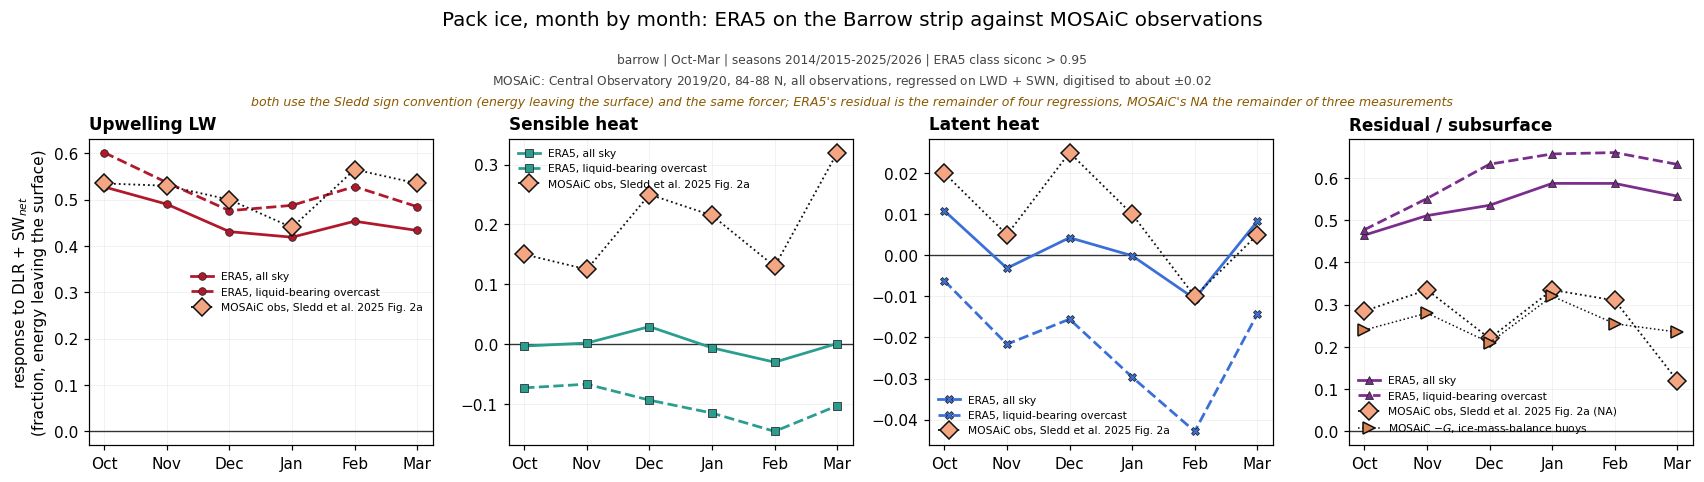

In [18]:
tfr.fig_monthly_vs_mosaic(A, out_dir=SAVE_DIR, dpi=DPI);

In [19]:
# The monthly numbers behind the comparison: ERA5 pack ice (both populations)
# against the digitised MOSAiC responses, on the DLR + SW_net forcer.
slot = tfr.SLOT_ORDER.index("sea_ice")
era = {pop: tfr.monthly_partition(A, slot, "fnet", pop) for pop in ("all", "cloud")}
S = tfr.SLEDD_FIG2A_WINTER
print(f"{'':>5}{'--- LWU ---':>22}{'--- SH ---':>22}{'--- LH ---':>22}{'--- residual ---':>28}")
print(f"{'':>5}{'all':>7}{'cloud':>7}{'MOSAiC':>8}{'all':>7}{'cloud':>7}{'MOSAiC':>8}"
      f"{'all':>7}{'cloud':>7}{'MOSAiC':>8}{'all':>7}{'cloud':>7}{'NA':>7}{'-G':>7}")
for i, (m, lab) in enumerate(zip(tfr.WINTER_MONTHS, tfr.WINTER_LABELS)):
    a, c = era["all"], era["cloud"]
    print(f"{lab:>5}{a['f_lwu'][i]:>7.3f}{c['f_lwu'][i]:>7.3f}{S['lwu'][m]:>8.3f}"
          f"{a['f_sh'][i]:>7.3f}{c['f_sh'][i]:>7.3f}{S['sh'][m]:>8.3f}"
          f"{a['f_lh'][i]:>7.3f}{c['f_lh'][i]:>7.3f}{S['lh'][m]:>8.3f}"
          f"{a['f_res'][i]:>7.3f}{c['f_res'][i]:>7.3f}{S['na'][m]:>7.3f}{S['g'][m]:>7.3f}")

                --- LWU ---            --- SH ---            --- LH ---            --- residual ---
         all  cloud  MOSAiC    all  cloud  MOSAiC    all  cloud  MOSAiC    all  cloud     NA     -G
  Oct  0.528  0.602   0.535 -0.003 -0.073   0.150  0.011 -0.006   0.020  0.465  0.477  0.285  0.240
  Nov  0.490  0.537   0.530  0.002 -0.067   0.125 -0.003 -0.022   0.005  0.511  0.551  0.335  0.280
  Dec  0.431  0.476   0.500  0.029 -0.093   0.250  0.004 -0.016   0.025  0.535  0.633  0.220  0.210
  Jan  0.419  0.488   0.440 -0.006 -0.115   0.215 -0.000 -0.030   0.010  0.587  0.657  0.335  0.320
  Feb  0.453  0.528   0.565 -0.030 -0.145   0.130 -0.011 -0.043  -0.010  0.587  0.660  0.310  0.255
  Mar  0.434  0.485   0.535  0.001 -0.103   0.320  0.008 -0.014   0.005  0.557  0.632  0.120  0.235


## 5. Hourly means against instantaneous values

Every variable in the archive is one or the other, and the split is clean:

| kind | variables | time base |
|---|---|---|
| **fluxes** | `msdwlwrf`, `msnlwrf`, `msnswrf`, `msshf`, `mslhf` | mean over the hour **ending** at the stamp |
| **state** | `skt`, `t2m`, `d2m`, `u10`, `v10`, `sp`, `tcc`, `tclw`, `tciw`, `siconc`, `istl1` | instantaneous **at** the stamp |

The [Copernicus Knowledge Base](https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation)
states the flux convention: mean rates "are over the hour ending at the
validity date/time." So a flux stamped 12:00 is the 11:00–12:00 mean, while
`skt` stamped 12:00 is the value at 12:00 — the *end* of that hour.

**Consequences, by regression type.**

- **Flux on flux** (every figure in §3, and everything regressed on DLR in the
  other notebook): both sides are hourly means over the *same* hour. Fully
  consistent. This is the right choice, and it is also the only choice —
  ERA5 offers no instantaneous radiation variable.
- **Flux on state** (λ_SH = slope of SHF on T_skin − T_2m; the closure test
  above): a mean over 11:00–12:00 against a difference at 12:00. This is the
  mismatch flagged in the other notebook as the reason a small-|ΔT| guard is
  needed. ERA5 does carry instantaneous turbulent fluxes — `ishf` (paramId
  231) and `ie` (232) — which would pair exactly with the instantaneous
  temperatures for λ_SH. They are not in this archive.

**Is instantaneous better?** For flux-on-flux, no: the hourly mean is the
consistent pair and it suppresses sub-hourly noise. For the λ regressions and
the closure test, yes in principle, and `ishf` is the clean fix for λ_SH; for
the closure it would not help, because R needs the radiation terms and those
exist only as means. The practical expectation is that the mismatch adds
scatter and a small slope bias to the closure, not a systematic failure, and
the r² and slope in §2 say how large it turned out to be.